# Ecommerce Customers - Model Evaluation

## Objective

The objective of this notebook is to evaluate the performance of the
Linear Regression model on unseen test data.

The evaluation includes:

- MAE
- MSE
- RMSE
- R²
- Comparison with a baseline model
- Actual vs predicted analysis
- Residual analysis
- Training vs testing performance
- Final interpretation of model performance

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/Ecommerce Customers.csv")

In [3]:
features = ["Avg. Session Length", "Time on App", "Time on Website", "Length of Membership"]

target = "Yearly Amount Spent"

In [4]:
X = df[features]
y = df[target]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.6 ,38.79, 0.31,61.9 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1044
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [7]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [9]:
baseline_prediction = y_train.mean()

y_baseline_pred = np.full(
    len(y_test),
    baseline_prediction
)

In [11]:
# On average, how far are our predictions from the actual values
mae = mean_absolute_error(y_test, y_test_pred)

mae

8.558441885315206

In [ ]:
# It squares the errors, so large errors are penalized more heavily
mse = mean_squared_error(y_test, y_test_pred)

mse

109.8637411839393

In [ ]:
# It takes back the error to the original unit as MSE squares the error
rmse = np.sqrt(mse)

rmse

np.float64(10.481590584636441)

In [ ]:
# How much of the variation in the target is explained by the model relative to a mean-based baseline
r2 = r2_score(y_test, y_test_pred)

r2

0.9778130629184129

In [15]:
baseline_mae = mean_absolute_error(y_test, y_baseline_pred)
baseline_mse = mean_squared_error(y_test, y_baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, y_baseline_pred)

In [16]:
evaluation = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression"],
    "MAE": [baseline_mae, mae],
    "MSE": [baseline_mse, mse],
    "RMSE": [baseline_rmse, rmse],
    "R²": [baseline_r2, r2]
})

evaluation

,Model,MAE,MSE,RMSE,R²
0,Baseline,54.910827,5131.038092,71.631265,-0.036211
1,Linear Regression,8.558442,109.863741,10.481591,0.977813


In [17]:
mae_improvement = ((baseline_mae - mae) / baseline_mae) * 100
rmse_improvement = ((baseline_rmse - rmse) / baseline_rmse) * 100

print(f"MAE improvement over baseline: {mae_improvement:.2f}%")
print(f"RMSE improvement over baseline: {rmse_improvement:.2f}%")

MAE improvement over baseline: 84.41%
RMSE improvement over baseline: 85.37%


In [18]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

results["Residual"] = (
    results["Actual"] - results["Predicted"]
)

results["Absolute_Error"] = (
    results["Residual"].abs()
)

results.head(10)

,Actual,Predicted,Residual,Absolute_Error
0,401.033135,402.862301,-1.829165,1.829165
1,534.777188,542.533257,-7.756069,7.756069
2,418.602742,426.620119,-8.017377,8.017377
3,503.978379,501.913864,2.064515,2.064515
4,410.069611,409.666655,0.402956,0.402956
5,557.608262,569.921550,-12.313288,12.313288
6,538.941975,531.504235,7.437739,7.437739
7,514.336558,505.943092,8.393466,8.393466
8,408.620188,408.103786,0.516402,0.516402
9,475.015407,473.459429,1.555978,1.555978


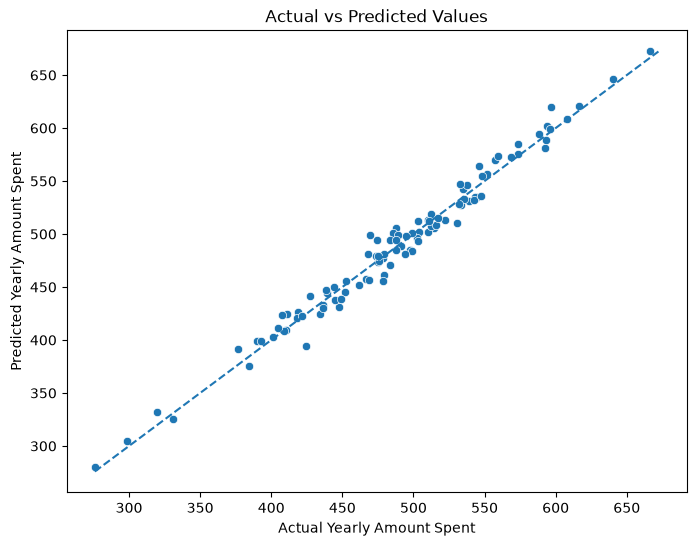

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=results,
    x="Actual",
    y="Predicted"
)

min_value = min(
    results["Actual"].min(),
    results["Predicted"].min()
)

max_value = max(
    results["Actual"].max(),
    results["Predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yearly Amount Spent")
plt.ylabel("Predicted Yearly Amount Spent")
plt.title("Actual vs Predicted Values")

plt.show()

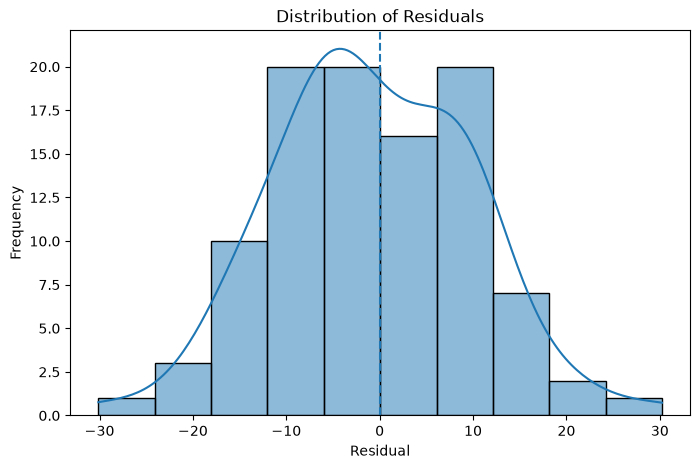

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=results,
    x="Residual",
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

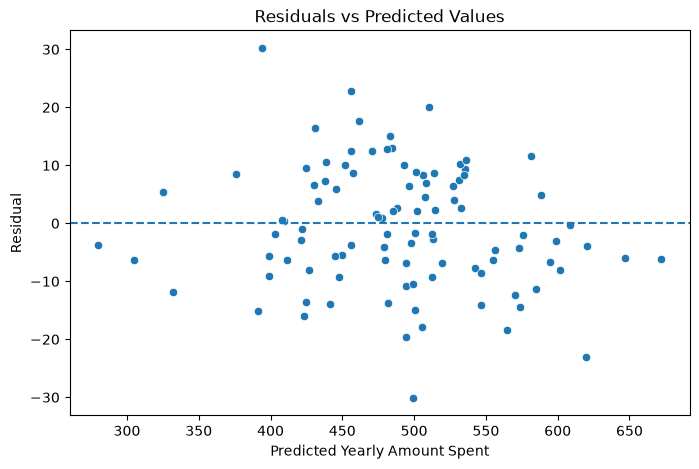

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=results,
    x="Predicted",
    y="Residual"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Yearly Amount Spent")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

In [22]:
train_mae = mean_absolute_error(y_train, y_train_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

train_r2 = r2_score(y_train, y_train_pred)

In [23]:
test_mae = mean_absolute_error(y_test, y_test_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

test_r2 = r2_score(y_test, y_test_pred)

In [25]:
performance_comparison = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R²": [train_r2, test_r2]
})

performance_comparison

,Dataset,MAE,RMSE,R²
0,Training,7.727001,9.788898,0.985424
1,Testing,8.558442,10.481591,0.977813


In [26]:
largest_errors = results.sort_values("Absolute_Error", ascending=False).head(10)

largest_errors

,Actual,Predicted,Residual,Absolute_Error
56,424.185494,393.955933,30.229561,30.229561
91,469.383146,499.506960,-30.123814,30.123814
81,596.430173,619.465550,-23.035377,23.035377
97,478.719357,455.930701,22.788656,22.788656
89,530.362469,510.339492,20.022977,20.022977
40,474.532329,494.112078,-19.579749,19.579749
54,545.945492,564.423130,-18.477638,18.477638
34,487.547505,505.468119,-17.920614,17.920614
76,479.172851,461.445877,17.726975,17.726975
14,447.369027,430.879855,16.489172,16.489172


In [27]:
results["Residual"].describe()

count    100.000000
mean      -0.698361
std       10.510987
min      -30.123814
25%       -7.135598
50%       -1.785379
75%        7.267726
max       30.229561
Name: Residual, dtype: float64

In [28]:
results["Residual"].mean()

np.float64(-0.6983614905662989)

# Model Interpretation

## Model Performance

The Linear Regression model was evaluated on the unseen test set using:

- MAE
- MSE
- RMSE
- R²

The model was also compared against a mean-based baseline.

## Error Analysis

Residuals were examined using:

- Residual distribution
- Residuals vs predicted values
- Largest absolute prediction errors

## Generalization

Training and testing performance were compared to understand whether
the model generalizes well to unseen observations.

## Interpretation

The model coefficients describe the estimated relationship between each
predictor and `Yearly Amount Spent`, while holding the other included
predictors constant.

Performance metrics should be interpreted together rather than relying
on a single metric.

# Final Conclusion

The Linear Regression model achieved:

- MAE: 8.5584
- RMSE: 10.4816
- R²: 0.9778

The baseline achieved:

- MAE: 54.9108
- RMSE: 71.6313
- R²: -0.0362

Compared with the baseline, the Linear Regression model [describe the
observed improvement using the actual results].

The actual-vs-predicted plot shows that the predictions are closely aligned with the actual values, with most observations lying near the 45° reference line. This indicates that the Linear Regression model is able to predict Yearly Amount Spent reasonably well on the test set. A few observations show larger deviations from the reference line, indicating higher prediction errors for those observations.

The residual distribution is approximately centered around zero and appears reasonably symmetric, with most residuals concentrated close to zero. This suggests that the model does not show a large systematic prediction bias. A small number of observations have relatively larger residuals, which correspond to the observations where the model's predictions deviate more from the actual values.

Overall, the results indicate that the selected customer behavioral
variables contain useful linear information for predicting `Yearly Amount
Spent`. However, the model's performance should be interpreted within
the limitations of this dataset and the assumptions of Linear Regression.